In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

In [4]:
PLANTVILLAGE_DIR = Path("../data/raw/plantvillage")
PLANTDOC_DIR = Path("../data/raw/plantdoc")

In [5]:
# See what folders exist inside plantvillage
pv_classes = sorted(os.listdir(PLANTVILLAGE_DIR))
print(f"Total PlantVillage classes: {len(pv_classes)}")
print("\nClasses:")
for c in pv_classes:
    print(c)

Total PlantVillage classes: 2

Classes:
New Plant Diseases Dataset(Augmented)
test


In [6]:
# Go deeper into the structure
for folder in os.listdir(PLANTVILLAGE_DIR):
    inner_path = PLANTVILLAGE_DIR / folder
    print(f"\n{folder}/")
    for subfolder in os.listdir(inner_path):
        print(f"  {subfolder}/")


New Plant Diseases Dataset(Augmented)/
  New Plant Diseases Dataset(Augmented)/

test/
  test/


In [7]:
for folder in os.listdir(PLANTVILLAGE_DIR):
    inner_path = PLANTVILLAGE_DIR / folder
    for subfolder in os.listdir(inner_path):
        inner_inner_path = inner_path / subfolder
        print(f"\n{folder}/{subfolder}/")
        for subsubfolder in os.listdir(inner_inner_path):
            print(f"  {subsubfolder}/")


New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/
  train/
  valid/

test/test/
  AppleCedarRust1.JPG/
  AppleCedarRust2.JPG/
  AppleCedarRust3.JPG/
  AppleCedarRust4.JPG/
  AppleScab1.JPG/
  AppleScab2.JPG/
  AppleScab3.JPG/
  CornCommonRust1.JPG/
  CornCommonRust2.JPG/
  CornCommonRust3.JPG/
  PotatoEarlyBlight1.JPG/
  PotatoEarlyBlight2.JPG/
  PotatoEarlyBlight3.JPG/
  PotatoEarlyBlight4.JPG/
  PotatoEarlyBlight5.JPG/
  PotatoHealthy1.JPG/
  PotatoHealthy2.JPG/
  TomatoEarlyBlight1.JPG/
  TomatoEarlyBlight2.JPG/
  TomatoEarlyBlight3.JPG/
  TomatoEarlyBlight4.JPG/
  TomatoEarlyBlight5.JPG/
  TomatoEarlyBlight6.JPG/
  TomatoHealthy1.JPG/
  TomatoHealthy2.JPG/
  TomatoHealthy3.JPG/
  TomatoHealthy4.JPG/
  TomatoYellowCurlVirus1.JPG/
  TomatoYellowCurlVirus2.JPG/
  TomatoYellowCurlVirus3.JPG/
  TomatoYellowCurlVirus4.JPG/
  TomatoYellowCurlVirus5.JPG/
  TomatoYellowCurlVirus6.JPG/


In [8]:
# Correct paths
PLANTVILLAGE_TRAIN = PLANTVILLAGE_DIR / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)" / "train"
PLANTVILLAGE_VAL   = PLANTVILLAGE_DIR / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)" / "valid"
PLANTVILLAGE_TEST  = PLANTVILLAGE_DIR / "test" / "test"

# Verify
print("Train path exists:", PLANTVILLAGE_TRAIN.exists())
print("Val path exists:", PLANTVILLAGE_VAL.exists())
print("Test path exists:", PLANTVILLAGE_TEST.exists())

Train path exists: True
Val path exists: True
Test path exists: True


In [9]:
pv_classes = sorted(os.listdir(PLANTVILLAGE_TRAIN))
print(f"Total PlantVillage classes: {len(pv_classes)}")
print()
for c in pv_classes:
    count = len(os.listdir(PLANTVILLAGE_TRAIN / c))
    print(f"{c}: {count} images")

Total PlantVillage classes: 38

Apple___Apple_scab: 2016 images
Apple___Black_rot: 1987 images
Apple___Cedar_apple_rust: 1760 images
Apple___healthy: 2008 images
Blueberry___healthy: 1816 images
Cherry_(including_sour)___Powdery_mildew: 1683 images
Cherry_(including_sour)___healthy: 1826 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 images
Corn_(maize)___Common_rust_: 1907 images
Corn_(maize)___Northern_Leaf_Blight: 1908 images
Corn_(maize)___healthy: 1859 images
Grape___Black_rot: 1888 images
Grape___Esca_(Black_Measles): 1920 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722 images
Grape___healthy: 1692 images
Orange___Haunglongbing_(Citrus_greening): 2010 images
Peach___Bacterial_spot: 1838 images
Peach___healthy: 1728 images
Pepper,_bell___Bacterial_spot: 1913 images
Pepper,_bell___healthy: 1988 images
Potato___Early_blight: 1939 images
Potato___Late_blight: 1939 images
Potato___healthy: 1824 images
Raspberry___healthy: 1781 images
Soybean___healthy: 2022 im

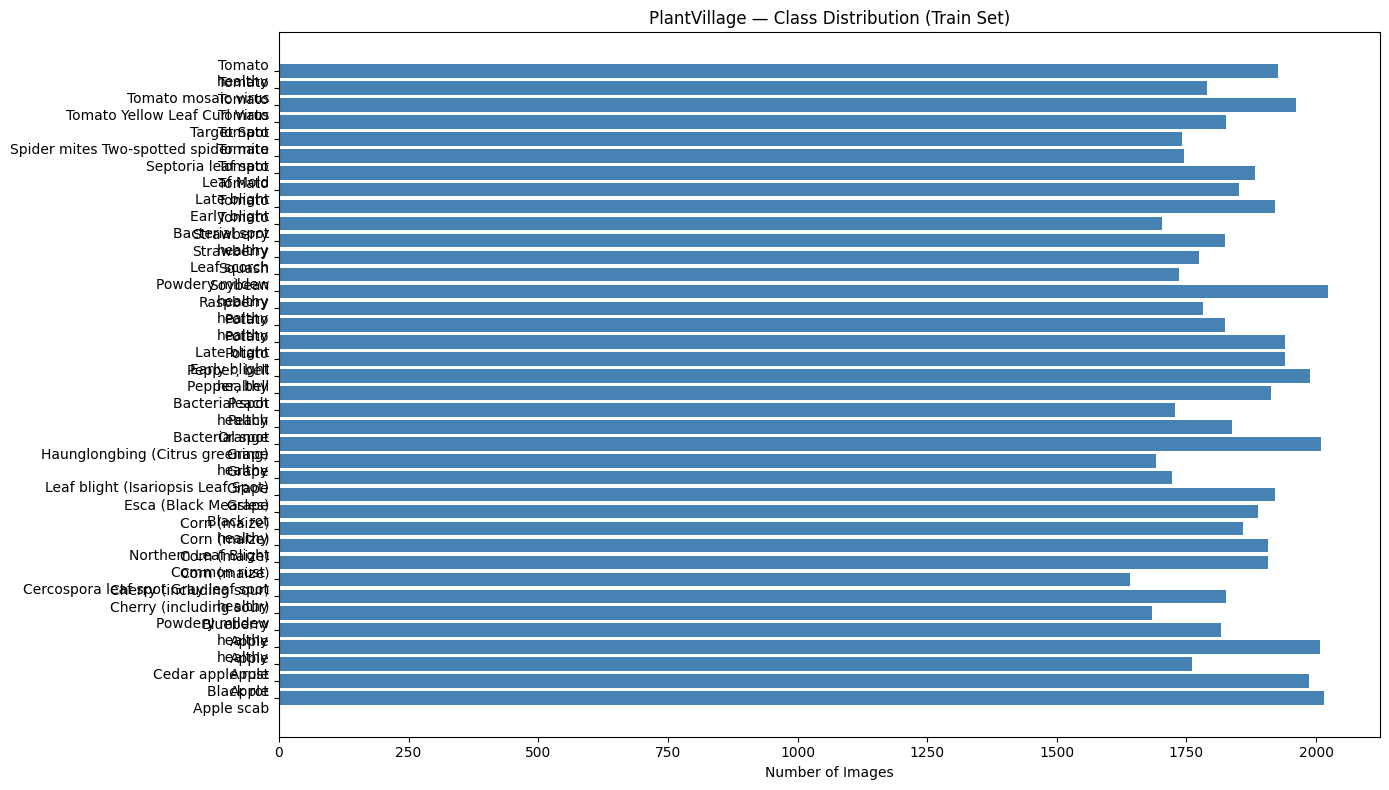


Min images in a class: 1642 — Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Max images in a class: 2022 — Soybean___healthy
Total train images: 70295


In [10]:
# Cell — Visualize class distribution
plt.figure(figsize=(14, 8))
classes = list(pv_classes)
counts = [len(os.listdir(PLANTVILLAGE_TRAIN / c)) for c in classes]

# Short names for readability
short_names = [c.replace("___", "\n").replace("_", " ") for c in classes]

bars = plt.barh(short_names, counts, color="steelblue")
plt.xlabel("Number of Images")
plt.title("PlantVillage — Class Distribution (Train Set)")
plt.tight_layout()
plt.show()

print(f"\nMin images in a class: {min(counts)} — {classes[counts.index(min(counts))]}")
print(f"Max images in a class: {max(counts)} — {classes[counts.index(max(counts))]}")
print(f"Total train images: {sum(counts)}")

In [11]:
# Explore PlantDoc structure
print("PlantDoc structure:")
for item in sorted(os.listdir(PLANTDOC_DIR)):
    print(f"  {item}/")

PlantDoc structure:
  file_renamer.py/
  folder_renamer.py/
  test/
  train/


In [12]:
PLANTDOC_TRAIN = PLANTDOC_DIR / "train"
PLANTDOC_TEST  = PLANTDOC_DIR / "test"

# Classes and image counts
pd_classes = sorted(os.listdir(PLANTDOC_TRAIN))
print(f"Total PlantDoc classes: {len(pd_classes)}")
print()
for c in pd_classes:
    count = len(os.listdir(PLANTDOC_TRAIN / c))
    print(f"{c}: {count} images")

Total PlantDoc classes: 28

Apple_Scab_Leaf: 83 images
Apple_leaf: 79 images
Apple_rust_leaf: 96 images
Bell_pepper_leaf: 34 images
Bell_pepper_leaf_spot: 74 images
Blueberry_leaf: 106 images
Cherry_leaf: 47 images
Corn_Gray_leaf_spot: 63 images
Corn_leaf_blight: 182 images
Corn_rust_leaf: 107 images
Peach_leaf: 103 images
Potato_leaf_early_blight: 157 images
Potato_leaf_late_blight: 200 images
Raspberry_leaf: 112 images
Soyabean_leaf: 57 images
Squash_Powdery_mildew_leaf: 124 images
Strawberry_leaf: 88 images
Tomato_Early_blight_leaf: 79 images
Tomato_Septoria_leaf_spot: 145 images
Tomato_leaf: 44 images
Tomato_leaf_bacterial_spot: 101 images
Tomato_leaf_late_blight: 101 images
Tomato_leaf_mosaic_virus: 44 images
Tomato_leaf_yellow_virus: 223 images
Tomato_mold_leaf: 85 images
Tomato_two_spotted_spider_mites_leaf: 2 images
grape_leaf: 63 images
grape_leaf_black_rot: 71 images


In [13]:
# Normalize both name lists for comparison
pv_normalized = [c.lower().replace("___", " ").replace("_", " ") for c in pv_classes]
pd_normalized = [c.lower().replace("_", " ") for c in pd_classes]


In [14]:
print("PlantVillage classes (normalized):")
for c in pv_normalized:
    print(f"  {c}")

PlantVillage classes (normalized):
  apple apple scab
  apple black rot
  apple cedar apple rust
  apple healthy
  blueberry healthy
  cherry (including sour) powdery mildew
  cherry (including sour) healthy
  corn (maize) cercospora leaf spot gray leaf spot
  corn (maize) common rust 
  corn (maize) northern leaf blight
  corn (maize) healthy
  grape black rot
  grape esca (black measles)
  grape leaf blight (isariopsis leaf spot)
  grape healthy
  orange haunglongbing (citrus greening)
  peach bacterial spot
  peach healthy
  pepper, bell bacterial spot
  pepper, bell healthy
  potato early blight
  potato late blight
  potato healthy
  raspberry healthy
  soybean healthy
  squash powdery mildew
  strawberry leaf scorch
  strawberry healthy
  tomato bacterial spot
  tomato early blight
  tomato late blight
  tomato leaf mold
  tomato septoria leaf spot
  tomato spider mites two-spotted spider mite
  tomato target spot
  tomato tomato yellow leaf curl virus
  tomato tomato mosaic viru

In [15]:

print("\nPlantDoc classes (normalized):")
for c in pd_normalized:
    print(f"  {c}")


PlantDoc classes (normalized):
  apple scab leaf
  apple leaf
  apple rust leaf
  bell pepper leaf
  bell pepper leaf spot
  blueberry leaf
  cherry leaf
  corn gray leaf spot
  corn leaf blight
  corn rust leaf
  peach leaf
  potato leaf early blight
  potato leaf late blight
  raspberry leaf
  soyabean leaf
  squash powdery mildew leaf
  strawberry leaf
  tomato early blight leaf
  tomato septoria leaf spot
  tomato leaf
  tomato leaf bacterial spot
  tomato leaf late blight
  tomato leaf mosaic virus
  tomato leaf yellow virus
  tomato mold leaf
  tomato two spotted spider mites leaf
  grape leaf
  grape leaf black rot


In [16]:
# Cell — Define canonical class mapping
# Format: "plantdoc_class" : "plantvillage_class (canonical name)"

PLANTDOC_TO_CANONICAL = {
    # Apple
    "Apple_Scab_Leaf"                        : "Apple___Apple_scab",
    "Apple_leaf"                             : "Apple___healthy",
    "Apple_rust_leaf"                        : "Apple___Cedar_apple_rust",

    # Bell Pepper
    "Bell_pepper_leaf"                       : "Pepper,_bell___healthy",
    "Bell_pepper_leaf_spot"                  : "Pepper,_bell___Bacterial_spot",

    # Blueberry
    "Blueberry_leaf"                         : "Blueberry___healthy",

    # Cherry
    "Cherry_leaf"                            : "Cherry_(including_sour)___healthy",

    # Corn
    "Corn_Gray_leaf_spot"                    : "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_leaf_blight"                       : "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_rust_leaf"                         : "Corn_(maize)___Common_rust_",

    # Grape
    "grape_leaf"                             : "Grape___healthy",
    "grape_leaf_black_rot"                   : "Grape___Black_rot",

    # Peach
    "Peach_leaf"                             : "Peach___healthy",

    # Potato
    "Potato_leaf_early_blight"               : "Potato___Early_blight",
    "Potato_leaf_late_blight"                : "Potato___Late_blight",

    # Raspberry
    "Raspberry_leaf"                         : "Raspberry___healthy",

    # Soybean
    "Soyabean_leaf"                          : "Soybean___healthy",

    # Squash
    "Squash_Powdery_mildew_leaf"             : "Squash___Powdery_mildew",

    # Strawberry
    "Strawberry_leaf"                        : "Strawberry___healthy",

    # Tomato
    "Tomato_Early_blight_leaf"               : "Tomato___Early_blight",
    "Tomato_Septoria_leaf_spot"              : "Tomato___Septoria_leaf_spot",
    "Tomato_leaf"                            : "Tomato___healthy",
    "Tomato_leaf_bacterial_spot"             : "Tomato___Bacterial_spot",
    "Tomato_leaf_late_blight"                : "Tomato___Late_blight",
    "Tomato_leaf_mosaic_virus"               : "Tomato___Tomato_mosaic_virus",
    "Tomato_leaf_yellow_virus"               : "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato_mold_leaf"                       : "Tomato___Leaf_Mold",

    # SKIP — only 2 images, not worth merging
    # "Tomato_two_spotted_spider_mites_leaf" : "Tomato___Spider_mites Two-spotted_spider_mite",
}

print(f"Total PlantDoc classes being mapped: {len(PLANTDOC_TO_CANONICAL)}")
print(f"Skipped: Tomato_two_spotted_spider_mites_leaf (only 2 images)")

Total PlantDoc classes being mapped: 27
Skipped: Tomato_two_spotted_spider_mites_leaf (only 2 images)


In [17]:
import shutil
from pathlib import Path

# Cell — Define processed output directory
PROCESSED_DIR = Path("../data/processed")
PROCESSED_TRAIN = PROCESSED_DIR / "train"
PROCESSED_VAL   = PROCESSED_DIR / "val"
PROCESSED_TEST  = PROCESSED_DIR / "test"

# Create directories
PROCESSED_TRAIN.mkdir(parents=True, exist_ok=True)
PROCESSED_VAL.mkdir(parents=True, exist_ok=True)
PROCESSED_TEST.mkdir(parents=True, exist_ok=True)

print("Processed directories created.")

Processed directories created.


In [21]:
# Cell — Copy PlantVillage train images into processed/train/
print("Copying PlantVillage train images...")

for class_name in pv_classes:
    src_dir = PLANTVILLAGE_TRAIN / class_name
    dst_dir = PROCESSED_TRAIN / class_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    images = list(src_dir.glob("*.*"))
    for img in images:
        shutil.copy2(img, dst_dir / img.name)

print(f"Done. Copied {len(pv_classes)} classes from PlantVillage train.")

Copying PlantVillage train images...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\pardhasai.inala\\Desktop\\PlantDisease\\data\\raw\\plantvillage\\New Plant Diseases Dataset(Augmented)\\New Plant Diseases Dataset(Augmented)\\train\\Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot\\00120a18-ff90-46e4-92fb-2b7a10345bd3___RS_GLSp 9357_270deg.JPG'

In [26]:
# Check what's actually inside one class folder
test_class = PLANTVILLAGE_TRAIN / "Apple___Cedar_apple_rust"
print("Path:", test_class)
print("Exists:", test_class.exists())
print("\nFirst 5 files:")
for f in list(test_class.iterdir())[:5]:
    print(f"  {f.name}")

Path: ..\data\raw\plantvillage\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train\Apple___Cedar_apple_rust
Exists: True

First 5 files:
  025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG
  025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655_180deg.JPG
  025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655_270deg.JPG
  025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655_90deg.JPG
  025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655_new30degFlipLR.JPG


In [19]:
# Cell — Use absolute paths to avoid Windows path length issues
import os

# Enable long path support
os.environ["PYTHONUTF8"] = "1"

# Convert all paths to absolute
PLANTVILLAGE_TRAIN = Path("../data/raw/plantvillage/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train").resolve()
PLANTVILLAGE_VAL   = Path("../data/raw/plantvillage/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid").resolve()
PROCESSED_TRAIN    = Path("../data/processed/train").resolve()
PROCESSED_VAL      = Path("../data/processed/val").resolve()

print("Train path:", PLANTVILLAGE_TRAIN)
print("Exists:", PLANTVILLAGE_TRAIN.exists())

Train path: C:\Users\pardhasai.inala\Desktop\PlantDisease\data\raw\plantvillage\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train
Exists: True


In [20]:
# One-time Windows long path fix
import subprocess
subprocess.run([
    "reg", "add",
    r"HKLM\SYSTEM\CurrentControlSet\Control\FileSystem",
    "/v", "LongPathsEnabled",
    "/t", "REG_DWORD",
    "/d", "1",
    "/f"
], capture_output=True)

print("Long path support enabled. Restart VS Code and try again.")

Long path support enabled. Restart VS Code and try again.


In [22]:
# Cell — Copy PlantDoc train images into processed/train/ using mapping
print("Copying PlantDoc train images...")

skipped = []
copied_counts = {}

for pd_class, pv_class in PLANTDOC_TO_CANONICAL.items():
    src_dir = PLANTDOC_TRAIN / pd_class
    dst_dir = PROCESSED_TRAIN / pv_class

    if not src_dir.exists():
        skipped.append(pd_class)
        continue

    dst_dir.mkdir(parents=True, exist_ok=True)
    images = list(src_dir.glob("*.*"))

    for img in images:
        # Prefix with "pd_" to avoid filename conflicts with PlantVillage
        dst_filename = f"pd_{img.name}"
        shutil.copy2(img, dst_dir / dst_filename)

    copied_counts[pd_class] = len(images)

print("\nPlantDoc classes copied:")
for cls, count in copied_counts.items():
    print(f"  {cls}: {count} images → {PLANTDOC_TO_CANONICAL[cls]}")

if skipped:
    print(f"\nSkipped (folder not found): {skipped}")

print(f"\nDone. Merged {len(copied_counts)} PlantDoc classes into processed/train.")

Copying PlantDoc train images...

PlantDoc classes copied:
  Apple_Scab_Leaf: 83 images → Apple___Apple_scab
  Apple_leaf: 79 images → Apple___healthy
  Apple_rust_leaf: 96 images → Apple___Cedar_apple_rust
  Bell_pepper_leaf: 34 images → Pepper,_bell___healthy
  Bell_pepper_leaf_spot: 74 images → Pepper,_bell___Bacterial_spot
  Blueberry_leaf: 106 images → Blueberry___healthy
  Cherry_leaf: 47 images → Cherry_(including_sour)___healthy
  Corn_Gray_leaf_spot: 63 images → Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  Corn_leaf_blight: 182 images → Corn_(maize)___Northern_Leaf_Blight
  Corn_rust_leaf: 107 images → Corn_(maize)___Common_rust_
  grape_leaf: 63 images → Grape___healthy
  grape_leaf_black_rot: 71 images → Grape___Black_rot
  Peach_leaf: 103 images → Peach___healthy
  Potato_leaf_early_blight: 157 images → Potato___Early_blight
  Potato_leaf_late_blight: 200 images → Potato___Late_blight
  Raspberry_leaf: 112 images → Raspberry___healthy
  Soyabean_leaf: 57 images → So

In [23]:
# Cell — Rename all files in processed/train/ to simple sequential names
print("Renaming files in processed/train/...\n")

total_renamed = 0

for class_name in sorted(os.listdir(PROCESSED_TRAIN)):
    class_dir = PROCESSED_TRAIN / class_name
    images = list(class_dir.glob("*.*"))
    
    for idx, img in enumerate(images):
        ext = img.suffix.lower()
        new_name = class_dir / f"img_{idx:04d}{ext}"
        img.rename(new_name)
    
    total_renamed += len(images)
    print(f"  {class_name}: {len(images)} files renamed")

print(f"\nTotal files renamed: {total_renamed}")

Renaming files in processed/train/...

  Apple___Apple_scab: 2099 files renamed
  Apple___Black_rot: 1987 files renamed
  Apple___Cedar_apple_rust: 1856 files renamed
  Apple___healthy: 2087 files renamed
  Blueberry___healthy: 1922 files renamed
  Cherry_(including_sour)___Powdery_mildew: 1683 files renamed
  Cherry_(including_sour)___healthy: 1873 files renamed
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1705 files renamed
  Corn_(maize)___Common_rust_: 2014 files renamed
  Corn_(maize)___Northern_Leaf_Blight: 2090 files renamed
  Corn_(maize)___healthy: 1859 files renamed
  Grape___Black_rot: 1959 files renamed
  Grape___Esca_(Black_Measles): 1920 files renamed
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722 files renamed
  Grape___healthy: 1755 files renamed
  Orange___Haunglongbing_(Citrus_greening): 2010 files renamed
  Peach___Bacterial_spot: 1838 files renamed
  Peach___healthy: 1831 files renamed
  Pepper,_bell___Bacterial_spot: 1987 files renamed
  Pepper,_bell__

In [25]:
# Cell — Rename all files in processed/val/
print("Renaming files in processed/val/...\n")

total_renamed = 0

for class_name in sorted(os.listdir(PROCESSED_VAL)):
    class_dir = PROCESSED_VAL / class_name
    images = list(class_dir.glob("*.*"))
    
    for idx, img in enumerate(images):
        ext = img.suffix.lower()
        new_name = class_dir / f"img_{idx:04d}{ext}"
        img.rename(new_name)
    
    total_renamed += len(images)
    print(f"  {class_name}: {len(images)} files renamed")

print(f"\nTotal files renamed: {total_renamed}")

Renaming files in processed/val/...

  Apple___Apple_scab: 504 files renamed
  Apple___Black_rot: 497 files renamed
  Apple___Cedar_apple_rust: 440 files renamed
  Apple___healthy: 502 files renamed
  Blueberry___healthy: 454 files renamed
  Cherry_(including_sour)___Powdery_mildew: 421 files renamed
  Cherry_(including_sour)___healthy: 456 files renamed
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410 files renamed
  Corn_(maize)___Common_rust_: 477 files renamed
  Corn_(maize)___Northern_Leaf_Blight: 477 files renamed
  Corn_(maize)___healthy: 465 files renamed
  Grape___Black_rot: 472 files renamed
  Grape___Esca_(Black_Measles): 480 files renamed
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 430 files renamed
  Grape___healthy: 423 files renamed
  Orange___Haunglongbing_(Citrus_greening): 503 files renamed
  Peach___Bacterial_spot: 459 files renamed
  Peach___healthy: 432 files renamed
  Pepper,_bell___Bacterial_spot: 478 files renamed
  Pepper,_bell___healthy: 497 files r

In [26]:
# Cell — Verify processed/train/
print("Verifying processed/train/...\n")

total = 0
for class_name in sorted(os.listdir(PROCESSED_TRAIN)):
    class_dir = PROCESSED_TRAIN / class_name
    images = list(class_dir.glob("*.*"))
    total += len(images)
    print(f"  {class_name}: {len(images)} images")

print(f"\nTotal classes: {len(os.listdir(PROCESSED_TRAIN))}")
print(f"Total images : {total}")

Verifying processed/train/...

  Apple___Apple_scab: 2099 images
  Apple___Black_rot: 1987 images
  Apple___Cedar_apple_rust: 1856 images
  Apple___healthy: 2087 images
  Blueberry___healthy: 1922 images
  Cherry_(including_sour)___Powdery_mildew: 1683 images
  Cherry_(including_sour)___healthy: 1873 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1705 images
  Corn_(maize)___Common_rust_: 2014 images
  Corn_(maize)___Northern_Leaf_Blight: 2090 images
  Corn_(maize)___healthy: 1859 images
  Grape___Black_rot: 1959 images
  Grape___Esca_(Black_Measles): 1920 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722 images
  Grape___healthy: 1755 images
  Orange___Haunglongbing_(Citrus_greening): 2010 images
  Peach___Bacterial_spot: 1838 images
  Peach___healthy: 1831 images
  Pepper,_bell___Bacterial_spot: 1987 images
  Pepper,_bell___healthy: 2022 images
  Potato___Early_blight: 2096 images
  Potato___Late_blight: 2139 images
  Potato___healthy: 1824 images
  Raspberry___

In [27]:
# Cell — Verify processed/val/
print("Verifying processed/val/...\n")

total = 0
for class_name in sorted(os.listdir(PROCESSED_VAL)):
    class_dir = PROCESSED_VAL / class_name
    images = list(class_dir.glob("*.*"))
    total += len(images)
    print(f"  {class_name}: {len(images)} images")

print(f"\nTotal classes: {len(os.listdir(PROCESSED_VAL))}")
print(f"Total images : {total}")

Verifying processed/val/...

  Apple___Apple_scab: 504 images
  Apple___Black_rot: 497 images
  Apple___Cedar_apple_rust: 440 images
  Apple___healthy: 502 images
  Blueberry___healthy: 454 images
  Cherry_(including_sour)___Powdery_mildew: 421 images
  Cherry_(including_sour)___healthy: 456 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410 images
  Corn_(maize)___Common_rust_: 477 images
  Corn_(maize)___Northern_Leaf_Blight: 477 images
  Corn_(maize)___healthy: 465 images
  Grape___Black_rot: 472 images
  Grape___Esca_(Black_Measles): 480 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 430 images
  Grape___healthy: 423 images
  Orange___Haunglongbing_(Citrus_greening): 503 images
  Peach___Bacterial_spot: 459 images
  Peach___healthy: 432 images
  Pepper,_bell___Bacterial_spot: 478 images
  Pepper,_bell___healthy: 497 images
  Potato___Early_blight: 485 images
  Potato___Late_blight: 485 images
  Potato___healthy: 456 images
  Raspberry___healthy: 445 images
  Soy

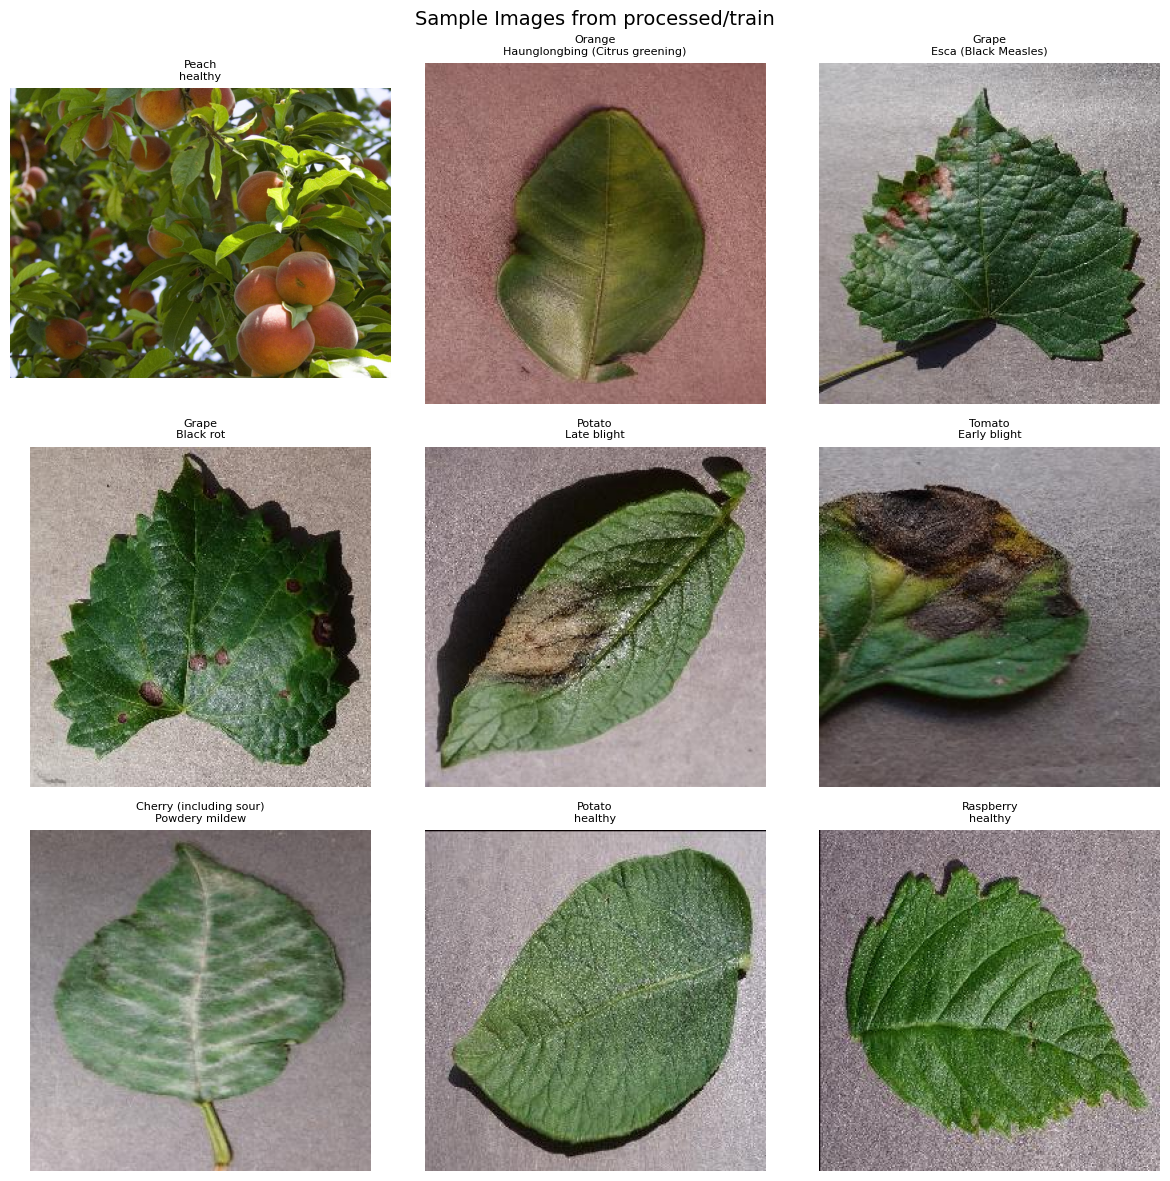

In [28]:
# Cell — Visualize sample images from random classes
import random
from PIL import Image

classes_to_show = random.sample(sorted(os.listdir(PROCESSED_TRAIN)), 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, class_name in enumerate(classes_to_show):
    class_dir = PROCESSED_TRAIN / class_name
    images = list(class_dir.glob("*.*"))
    sample_img_path = random.choice(images)
    
    img = Image.open(sample_img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(
        class_name.replace("___", "\n").replace("_", " "),
        fontsize=8
    )
    axes[idx].axis("off")

plt.suptitle("Sample Images from processed/train", fontsize=14)
plt.tight_layout()
plt.show()